# Backtesting Trimestral 2025 — CNN Deep Conv1D (Target Relativo)

Análisis comparativo de **5 estrategias** de inversión sobre el universo de 23 activos durante 2025,
con rebalanceo trimestral. A diferencia del notebook base, el modelo CNN aquí fue entrenado con
**target relativo al universo**: el exceso de retorno de cada activo respecto a la media del universo
en la ventana de salida, en lugar de la media absoluta.

| Estrategia | Descripción |
|---|---|
| `cnn_top4_equal` | Top-4 por exceso de retorno predicho; pesos iguales |
| `cnn_top4_riskadjusted` | Top-4 por exceso predicho / volatilidad trailing |
| `cnn_top4_threshold` | Como Equal, pero solo activos con predicción > umbral; resto en cash |
| `bench_momentum` | Top-4 por retorno realizado en los últimos 90 días |
| `bench_equalweight` | Buy & Hold con peso igual en los 23 activos |

**Modelo**: CNN Deep Conv1D (input = 10 días, output = exceso de retorno medio a 90 días)  
**Entrenamiento**: datos hasta 31-dic-2024 | **Test out-of-sample**: 2025

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches

# Añadimos project root, model/cnn y scripts al path
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parents[1]
SCRIPTS_DIR = NOTEBOOK_DIR.parent / "scripts"

for _p in [str(PROJECT_ROOT), str(PROJECT_ROOT / "model" / "cnn"), str(SCRIPTS_DIR)]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import backtest_cnn_quarterly_momentum as bt

# relative=True carga cnn_input10_output90_rel_model.keras y ajusta el scaler
# con el mismo pipeline usado durante el entrenamiento relativo.
bt.setup(input_window=10, output_window=90, relative=True)

Modelo cargado: data/cnn/saved_models/cnn_input10_output90_rel_model.keras
Scaler ajustado sobre 12764 secuencias (10d × 23 activos).
Universo: 23 activos | 2025: 2025-01-02 → 2025-12-31 (250 días)
Periodos de rebalanceo (4):
  Q1: 2025-01-02 → 2025-03-31
  Q2: 2025-04-01 → 2025-06-30
  Q3: 2025-07-01 → 2025-09-30
  Q4: 2025-10-01 → 2025-12-31


## 1. Universo de activos

El universo está compuesto por **23 acciones del mercado estadounidense** (NYSE/NASDAQ).
Mostramos las estadísticas de retorno logarítmico diario durante el periodo de test (2025).

In [2]:
returns_2025 = bt.returns_full.loc["2025"]

print(f"Periodo out-of-sample : {returns_2025.index[0].date()} → {returns_2025.index[-1].date()}")
print(f"Días de trading       : {len(returns_2025)}")
print(f"\nActivos ({bt.n_assets}):")
print(bt.assets)

# Estadísticas de retorno diario en porcentaje
stats = (returns_2025.describe().T[["mean", "std", "min", "max"]] * 100).round(4)
stats.columns = ["Media diaria (%)", "Vol. diaria (%)", "Mínimo (%)", "Máximo (%)"]
display(stats.sort_values("Media diaria (%)", ascending=False))

Periodo out-of-sample : 2025-01-02 → 2025-12-31
Días de trading       : 250

Activos (23):
['AEP', 'BA', 'CAT', 'CNP', 'CVX', 'DIS', 'DTE', 'ED', 'GD', 'GE', 'HON', 'HPQ', 'IBM', 'IP', 'JNJ', 'KO', 'KR', 'MMM', 'MO', 'MRK', 'MSI', 'PG', 'XOM']


,Media diaria (%),Vol. diaria (%),Mínimo (%),Máximo (%)
Ticker,,,,
GE,0.2477,1.9178,-11.7617,10.0466
CAT,0.1888,2.0022,-9.0315,11.0061
JNJ,0.1554,1.2355,-7.8953,6.0090
IBM,0.1295,1.8824,-7.9301,12.1900
GD,0.1062,1.3355,-7.5513,6.5128
AEP,0.1030,1.2192,-4.3361,5.9034
MMM,0.0936,1.8608,-9.6305,8.4124
CNP,0.0852,1.0415,-3.4862,2.8763
BA,0.0817,2.3586,-11.0608,14.3010


## 2. Predicciones del CNN en cada rebalanceo

En cada fecha de rebalanceo el modelo recibe los **últimos 10 días de retornos** de los 23 activos
y predice el **exceso de retorno diario medio** de cada activo respecto a la media del universo
en los próximos 90 días.

> **Interpretación del eje X**: la predicción (exceso de retorno diario) se multiplica × 252
> para aproximar un exceso de retorno anualizado. Un valor positivo indica que el modelo espera
> que el activo supere a la media del universo; negativo, que la infrapondere.
> Los activos en azul son los 4 seleccionados.

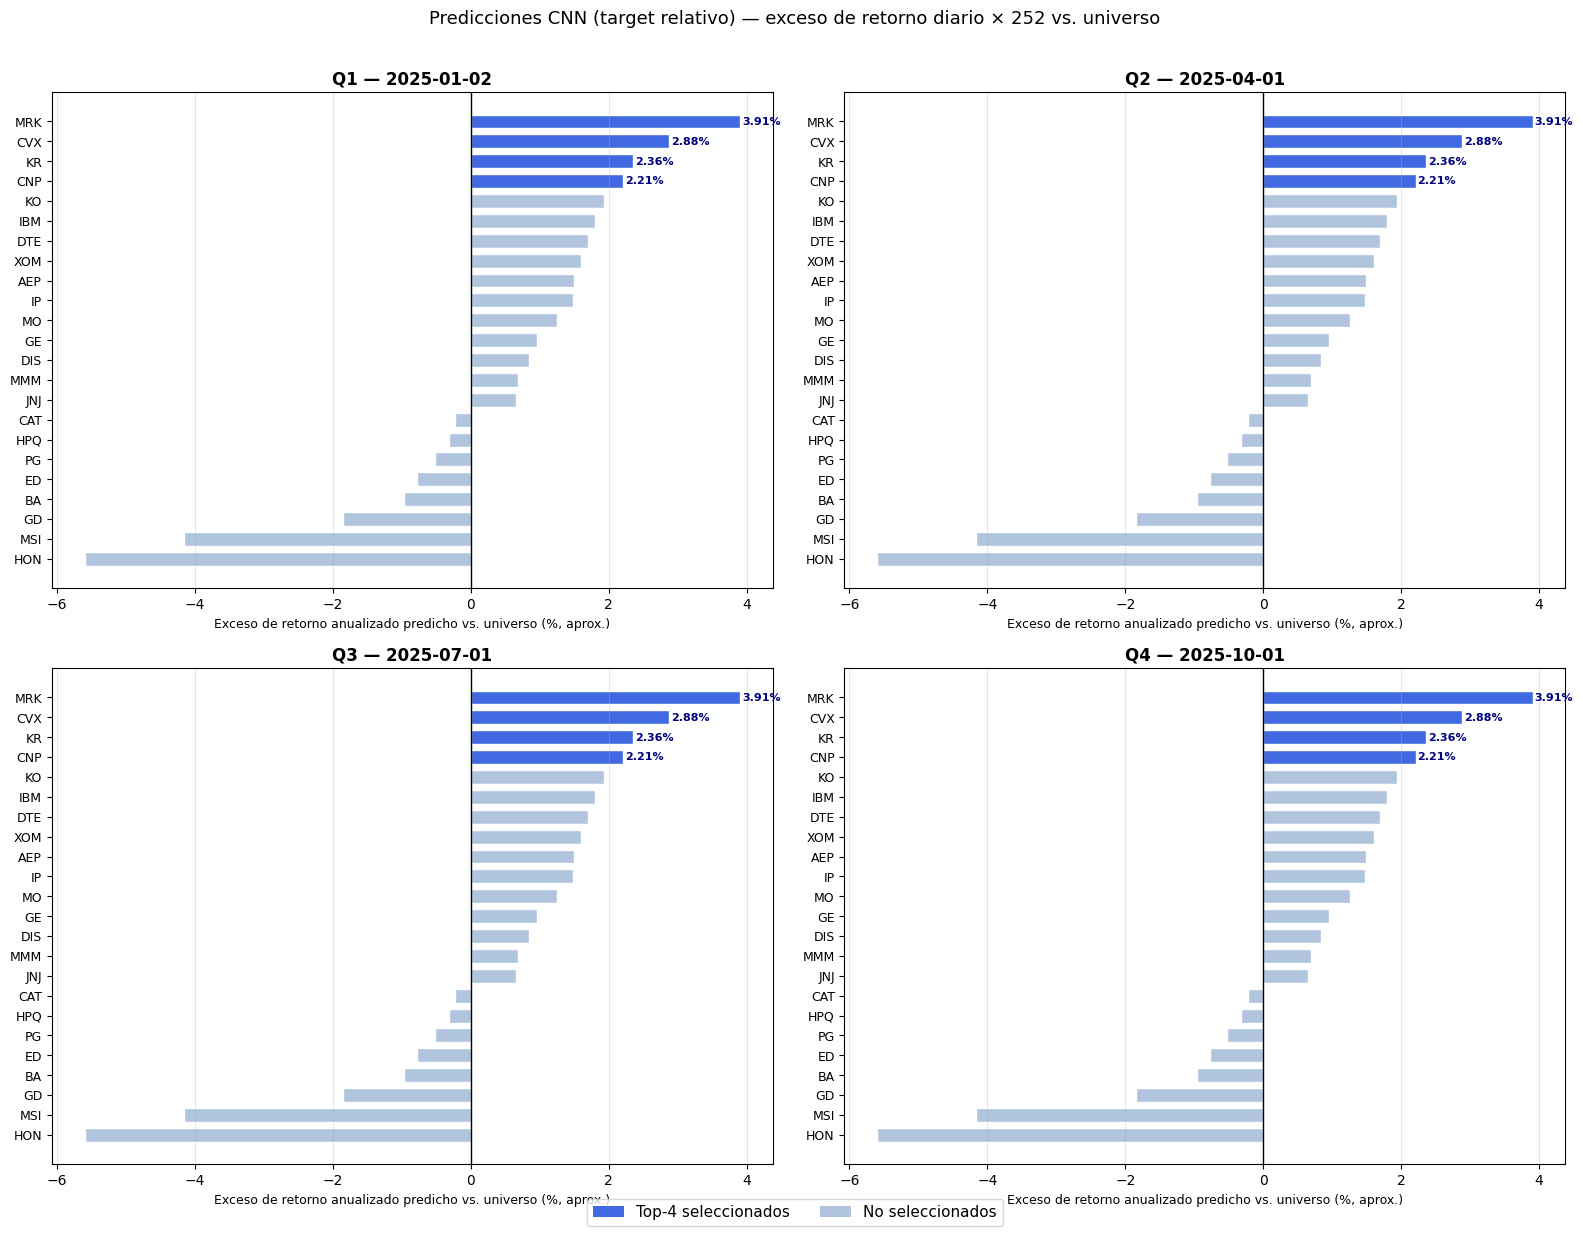

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for q_idx, (rb_date, ax) in enumerate(zip(bt.rebalance_dates, axes)):
    pred = bt.predict_at(rb_date)
    top4_idx = set(int(i) for i in np.argsort(pred)[::-1][:bt.N_TOP])
    order = list(np.argsort(pred))

    sorted_assets = [bt.assets[j] for j in order]
    pred_annual   = [float(pred[j]) * 252 * 100 for j in order]
    colors        = ["royalblue" if j in top4_idx else "lightsteelblue" for j in order]

    bars = ax.barh(sorted_assets, pred_annual, color=colors, edgecolor="white", height=0.7)
    ax.axvline(0, color="black", lw=1)
    ax.set_title(f"Q{q_idx + 1} — {rb_date.strftime('%Y-%m-%d')}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Exceso de retorno anualizado predicho vs. universo (%, aprox.)", fontsize=9)
    ax.grid(True, alpha=0.3, axis="x")
    ax.tick_params(axis="y", labelsize=9)

    for j_pos, (bar, val, j) in enumerate(zip(bars, pred_annual, order)):
        if j in top4_idx:
            ax.text(
                val + 0.03, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f}%", va="center", fontsize=8, color="navy", fontweight="bold",
            )

legend_elems = [
    mpatches.Patch(facecolor="royalblue",      label="Top-4 seleccionados"),
    mpatches.Patch(facecolor="lightsteelblue", label="No seleccionados"),
]
fig.legend(handles=legend_elems, loc="lower center", ncol=2, fontsize=11, bbox_to_anchor=(0.5, -0.01))
fig.suptitle(
    "Predicciones CNN (target relativo) — exceso de retorno diario × 252 vs. universo",
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()

## 3. Ejecución del backtest

Ejecutamos el backtest trimestral para las 5 estrategias y mostramos qué activos selecciona cada una en cada periodo.

In [4]:
ret_df, holdings = bt.run_backtest()

LABELS = {
    "cnn_top4_equal":        "CNN Equal",
    "cnn_top4_riskadjusted": "CNN Risk-Adj.",
    "cnn_top4_threshold":    "CNN Umbral",
    "bench_momentum":        "Momentum",
    "bench_equalweight":     "Equal Weight",
}

# Tabla de selección de activos por trimestre
quarter_names = [f"Q{i+1} ({d.strftime('%b %Y')})" for i, d in enumerate(bt.rebalance_dates)]
rows = {}
for name, label in LABELS.items():
    row = []
    for q in range(len(bt.rebalance_dates)):
        if q < len(holdings[name]):
            h = holdings[name][q]
            if name == "bench_equalweight":
                row.append("todos (1/23)")
            elif not h:
                row.append("cash")
            else:
                row.append(", ".join(sorted(h)))
        else:
            row.append("—")
    rows[label] = row

sel_df = pd.DataFrame(rows, index=quarter_names).T
display(sel_df)

Q1 (2025-01-02): pred top-4 = ['MRK', 'CVX', 'KR', 'CNP']
Q2 (2025-04-01): pred top-4 = ['MRK', 'CVX', 'KR', 'CNP']
Q3 (2025-07-01): pred top-4 = ['MRK', 'CVX', 'KR', 'CNP']
Q4 (2025-10-01): pred top-4 = ['MRK', 'CVX', 'KR', 'CNP']


,Q1 (Jan 2025),Q2 (Apr 2025),Q3 (Jul 2025),Q4 (Oct 2025)
CNN Equal,"CNP, CVX, KR, MRK","CNP, CVX, KR, MRK","CNP, CVX, KR, MRK","CNP, CVX, KR, MRK"
CNN Risk-Adj.,"CNP, CVX, KO, MRK","CNP, CVX, KO, MRK","CNP, CVX, KO, MRK","CNP, CVX, KO, MRK"
CNN Umbral,"CVX, MRK","CVX, MRK","CVX, MRK","CVX, MRK"
Momentum,"CNP, DIS, HON, KR","BA, CNP, IBM, KO","BA, GD, GE, MO","CAT, GD, GE, JNJ"
Equal Weight,todos (1/23),todos (1/23),todos (1/23),todos (1/23)


## 4. Retorno acumulado

Evolución del valor de la cartera (base 100) a lo largo de 2025.
Las líneas verticales punteadas marcan las fechas de rebalanceo trimestral.

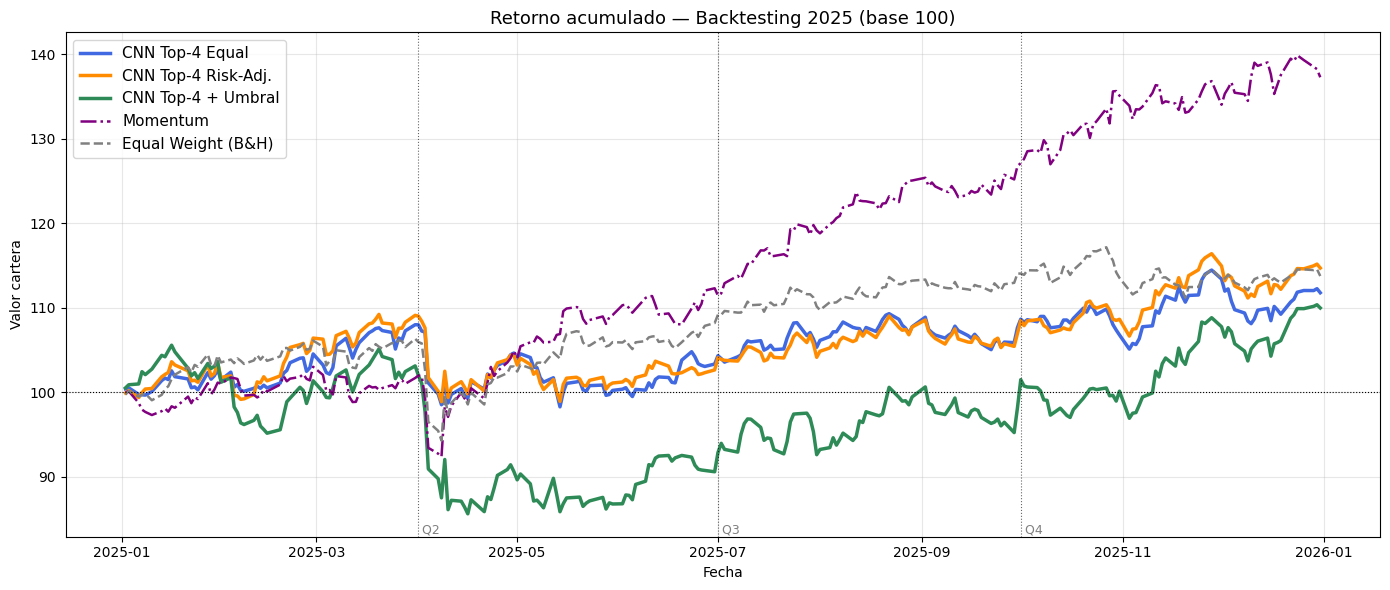

Retorno final (base 100):
  CNN Top-4 Equal               : 111.75  (+11.75 %)
  CNN Top-4 Risk-Adj.           : 114.67  (+14.67 %)
  CNN Top-4 + Umbral            : 109.95  (+9.95 %)
  Momentum                      : 137.25  (+37.25 %)
  Equal Weight (B&H)            : 113.73  (+13.73 %)


In [5]:
cum_value = ret_df.cumsum().apply(np.exp) * 100

STYLE = {
    "cnn_top4_equal":        dict(color="royalblue",  lw=2.5, ls="-",  label="CNN Top-4 Equal"),
    "cnn_top4_riskadjusted": dict(color="darkorange", lw=2.5, ls="-",  label="CNN Top-4 Risk-Adj."),
    "cnn_top4_threshold":    dict(color="seagreen",   lw=2.5, ls="-",  label="CNN Top-4 + Umbral"),
    "bench_momentum":        dict(color="purple",     lw=1.8, ls="-.", label="Momentum"),
    "bench_equalweight":     dict(color="gray",       lw=1.8, ls="--", label="Equal Weight (B&H)"),
}

fig, ax = plt.subplots(figsize=(14, 6))
for name, style in STYLE.items():
    ax.plot(cum_value.index, cum_value[name], **style)

for i, rb in enumerate(bt.rebalance_dates[1:], start=2):
    ax.axvline(rb, color="black", lw=0.8, ls=":", alpha=0.6)
    ax.text(rb, ax.get_ylim()[0], f" Q{i}", fontsize=9, color="gray", va="bottom")

ax.axhline(100, color="black", lw=0.8, ls=":")
ax.set_title("Retorno acumulado — Backtesting 2025 (base 100)", fontsize=13)
ax.set_xlabel("Fecha")
ax.set_ylabel("Valor cartera")
ax.legend(fontsize=11, loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Retorno final (base 100):")
for name, style in STYLE.items():
    final = float(cum_value[name].iloc[-1])
    print(f"  {style['label']:30s}: {final:.2f}  ({final - 100:+.2f} %)")

## 5. Métricas de rendimiento

| Métrica | Descripción |
|---|---|
| **Retorno total (%)** | Ganancia acumulada en 2025 |
| **Sharpe ratio** | Retorno ajustado por riesgo (rf = 4 % anual) |
| **Max Drawdown (%)** | Caída máxima desde un máximo histórico |
| **Turnover medio** | Fracción de activos cambiados entre trimestres (0 = sin cambios, 1 = cartera completamente nueva) |

,Retorno (%),Sharpe,Max DD (%),Turnover
CNN Equal,11.75,0.498,-9.00,0.000
CNN Risk-Adj.,14.67,0.669,-9.46,0.000
CNN Umbral,9.95,0.256,-18.91,0.000
Momentum,37.25,1.726,-10.33,1.333
Equal Weight,13.73,0.653,-11.33,0.000


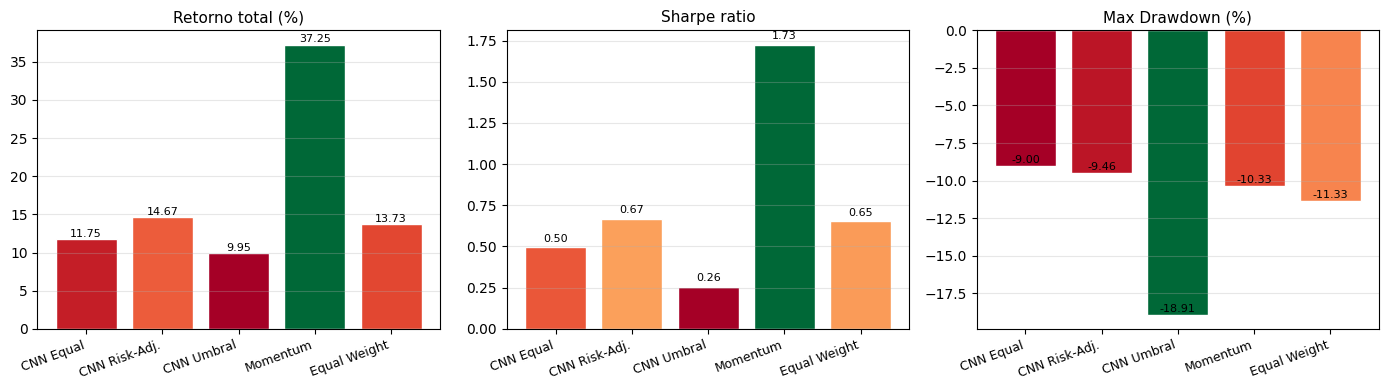

In [6]:
metrics_rows = [bt.compute_metrics(n, ret_df, holdings) for n in bt.STRATEGIES]
metrics = pd.DataFrame(metrics_rows).set_index("strategy")
metrics.index = [LABELS.get(n, n) for n in metrics.index]
metrics.columns = ["Retorno (%)", "Sharpe", "Max DD (%)", "Turnover"]

display(
    metrics.style
    .format({"Retorno (%)": "{:.2f}", "Sharpe": "{:.3f}", "Max DD (%)": "{:.2f}", "Turnover": "{:.3f}"})
    .background_gradient(subset=["Retorno (%)"], cmap="RdYlGn")
    .background_gradient(subset=["Sharpe"],      cmap="RdYlGn")
    .background_gradient(subset=["Max DD (%)"],  cmap="RdYlGn_r")
    .set_caption("Métricas de backtesting 2025")
)

# Gráfico de barras comparativo
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
cols   = ["Retorno (%)", "Sharpe", "Max DD (%)"]
cmaps  = ["RdYlGn", "RdYlGn", "RdYlGn_r"]
titles = ["Retorno total (%)", "Sharpe ratio", "Max Drawdown (%)"]

for ax, col, cmap_name, title in zip(axes, cols, cmaps, titles):
    vals   = metrics[col]
    cmap   = plt.get_cmap(cmap_name)
    norm   = plt.Normalize(vals.min(), vals.max())
    colors = [cmap(norm(v)) for v in vals]
    bars   = ax.bar(range(len(vals)), vals, color=colors, edgecolor="white")
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(vals.index, rotation=20, ha="right", fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.3, axis="y")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f"{v:.2f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

## 6. Análisis de drawdown

El drawdown mide la caída porcentual respecto al máximo histórico de la cartera.
Es el indicador de riesgo más visible para un inversor real.

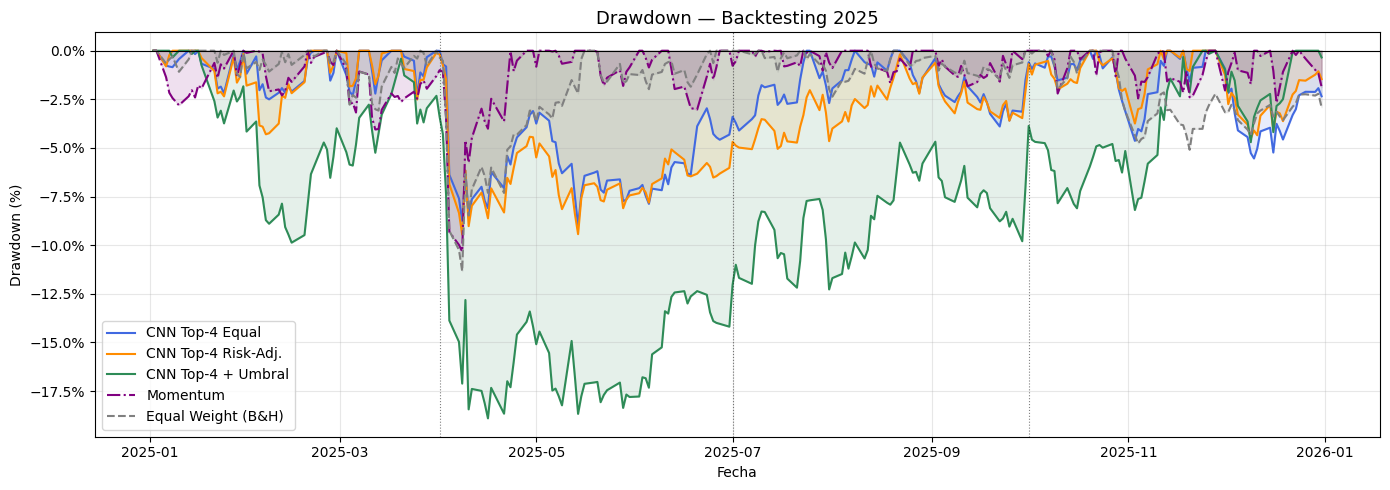

Max Drawdown por estrategia:
  CNN Top-4 Equal               : -9.00 %
  CNN Top-4 Risk-Adj.           : -9.46 %
  CNN Top-4 + Umbral            : -18.91 %
  Momentum                      : -10.33 %
  Equal Weight (B&H)            : -11.33 %


In [7]:
fig, ax = plt.subplots(figsize=(14, 5))

for name, style in STYLE.items():
    cum = ret_df[name].cumsum().apply(np.exp)
    dd  = (cum - cum.cummax()) / cum.cummax() * 100
    ax.fill_between(dd.index, dd, 0, alpha=0.12, color=style["color"])
    ax.plot(dd.index, dd, lw=1.5, color=style["color"], ls=style["ls"], label=style["label"])

for rb in bt.rebalance_dates[1:]:
    ax.axvline(rb, color="black", lw=0.8, ls=":", alpha=0.5)

ax.axhline(0, color="black", lw=0.8)
ax.set_title("Drawdown — Backtesting 2025", fontsize=13)
ax.set_xlabel("Fecha")
ax.set_ylabel("Drawdown (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=1))
ax.legend(fontsize=10, loc="lower left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Max Drawdown por estrategia:")
for name, style in STYLE.items():
    cum = ret_df[name].cumsum().apply(np.exp)
    dd  = (cum - cum.cummax()) / cum.cummax() * 100
    print(f"  {style['label']:30s}: {float(dd.min()):.2f} %")

## 7. Análisis del target relativo

### 7.1 Motivación

El notebook base (`backtest_analysis_momentum.ipynb`) identificó que el modelo CNN entrenado con
**target absoluto** (media del log-return diario en los próximos 90 días) producía un **ranking
estático**: seleccionaba exactamente los mismos 4 activos (BA, JNJ, KR, MO) en los cuatro
trimestres, con turnover = 0.

La causa raíz era que el modelo aprendía qué activos son estructuralmente más rentables a largo
plazo, pero no qué activos van a *destacar en el próximo trimestre* respecto al resto.

Este notebook evalúa la solución propuesta: entrenar con **target relativo al universo**.

---

### 7.2 Qué cambia con el target relativo

El nuevo target es, para cada muestra `i` y activo `j`:

```
y[i, j] = mean(ret[j, i+input : i+input+output])
          − mean_sobre_activos(mean(ret[:, i+input : i+input+output]))
```

Al centrar el target en cada periodo de entrenamiento, el modelo ya no puede aprender
que ciertos activos son *siempre* mejores en términos absolutos. Se ve obligado a aprender
**señales que discriminan entre activos dentro del mismo periodo**, que es exactamente
lo que necesita un selector de cartera trimestral.

| Aspecto | Target absoluto | Target relativo |
|---|---|---|
| Lo que aprende el modelo | Rentabilidad histórica media de cada activo | Qué activos superan al universo en cada periodo |
| Turnover esperado | Bajo (ranking estático) | Mayor (ranking dinámico) |
| Sensibilidad a la ventana de entrada | Baja | Mayor |
| Interpretación de la predicción | Retorno medio absoluto | Exceso de retorno vs. universo |

---

### 7.3 Cómo leer los resultados de este notebook

- **Si el turnover de las estrategias CNN es > 0**: el modelo ha aprendido señales dinámicas
  y rota la cartera entre trimestres, a diferencia del modelo absoluto.
- **Si el retorno / Sharpe mejoran respecto al benchmark**: el target relativo añade valor
  de selección por encima del momentum puro.
- **Si el turnover sigue siendo 0**: la ventana de entrada de 10 días sigue siendo insuficiente
  para capturar diferencias entre periodos; habría que ampliarla o añadir features adicionales.